  0%|          | 0/100000 [00:00<?, ?it/s]

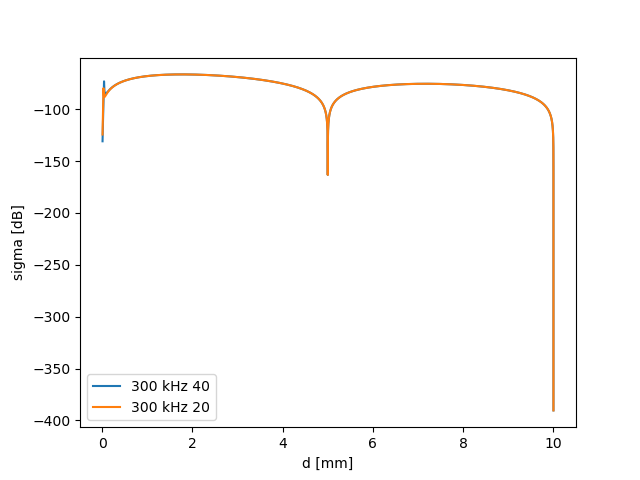

In [22]:
# SPDX-FileCopyrightText: 2022 GEOMAR Helmholtz Centre for Ocean Research Kiel
#
# SPDX-License-Identifier: MPL-2.0
%matplotlib widget
from scipy import signal
from math import pi
import math
import numpy as np
from matplotlib import pyplot as plt
from numba import njit

class calc_flow(object):

    #constants
    # self.temp=4;               #temperature (celcius??)
    # cw=1500;              #sound velocity [m/s]
    ethas = 0.0014    # shear viscosity ?? 0.00159? [Pa/s]
    rhow  = 1000      # water density [kg/m²]
    cp    = 2191      # ??part of thermal diffusity??
    gamma = 1.4       # specific heat ratio
    kcond = 0.03057   # ??part of thermal diffusity??
    rhoG0=0.66        # Atmospheric CH4 density [kg/m³]
    Pst0=101.325      # Atmospheric preasure [Pa]
    g=9.8             # acceleration of gravity m/s[]
    sigma=0.074       #surface tension water [N/m]
    
    # r_aver=0.003      #averate bubble radius in ,m
    
    
    #easy flow calculations
    calibration_factor_dB = 16.5
    # bubble_radius = 0.003
    # mass_bubble_radius = 0.003 #radius where the mass is calculated
    bubble_rising_speed = 0.25
    mass_layer_depth = -40 #None means same as layer_depth
    mass_layer_depth = None
    
    def __init__(self):        
        pass
    
    @staticmethod
    def easy_calc_flow(
            sum_avgAvox_db,
            frequency,
            layer_depth,
            bubble_radius,
            ):
        
            cls = calc_flow()
        
            if cls.mass_layer_depth is None: 
                mass_layer_depth = layer_depth
            else:   
                mass_layer_depth = cls.mass_layer_depth
            
            flow_LM = cls.calc_volume_flow_LM( 
                                                                    TS = sum_avgAvox_db,
                                                                     layer_size = 1,                #TS
                                                                     layer_depth = layer_depth,
                                                                     calibration_factor_dB = cls.calibration_factor_dB, 
                                                                     frequency = frequency,
                                                                     bubble_radius = bubble_radius,
                                                                 bubble_rising_speed = cls.bubble_rising_speed)
    
    
            flow_TY = cls.convert_LM_TY(flow_LM,
                                     depth = mass_layer_depth,
                                     bubble_radius = bubble_radius)
            
            return flow_LM,flow_TY
        
    
    
    
    
    def calc_mbes_TS(self,
                              sum_avgAvox_dB,
                              voxel_size):
        print("peter",sum_avgAvox_dB + 10*math.log10(voxel_size))
        return sum_avgAvox_dB + 10*math.log10(voxel_size)
    
    
    def convert_LM_TY(self,
                      flow_LM, 
                      depth,
                      bubble_radius
                      ):
        Pst = self.Pst0 + self.rhow * self.g * abs(depth) #static pressure at depth [PA]
        
        rhoG = self.rhoG0* (1+ 2*self.sigma/(Pst*bubble_radius)) * (1+0.1*abs(depth))
        
        
        return rhoG * flow_LM *60*24*365/1000/1000
    
    def calc_volume_flow_LM_mbes(self,
                             sum_avgAvox_dB,
                              voxel_size,
                              layer_size,
                              layer_depth,
                              calibration_factor_dB, 
                              frequency,
                              bubble_radius, 
                              bubble_rising_speed):
        
        return self.calc_volume_flow_LM(
                 self.calc_mbes_TS(sum_avgAvox_dB,voxel_size),
                 layer_size,
                 layer_depth,
                 calibration_factor_dB, 
                 frequency,
                 bubble_radius, 
                 bubble_rising_speed)
    
    
    
    def calc_volume_flow_LM(self,TS,
                              layer_size,
                              layer_depth,
                              calibration_factor_dB, 
                              frequency,
                              bubble_radius, 
                              bubble_rising_speed):
        
        reference_radius = 1  #r0 -> 1 m²

        r0  =  reference_radius
        Ub = bubble_rising_speed
        
        sigma_bs = self.calculate_sigma_bs(depth = layer_depth, freq  = frequency, bubble_radius = bubble_radius)
        
        flowrate_factor = Ub * (r0**2) * (4/3) * pi * (bubble_radius**3) * (1/sigma_bs)
        calib_factor = 10**(-calibration_factor_dB/10)
        ts = 10**(TS/10)

        flowrate = flowrate_factor * calib_factor * ts / layer_size

        volume_flow_liter_per_minute = flowrate*1000*60
        
        return volume_flow_liter_per_minute
        


    def calculate_sigma_bs(self,depth,freq,bubble_radius=None, sound_speed = 1500.0):
    
        if bubble_radius is None: r = self.r_aver
        else: r = bubble_radius
        #  buovel clean bubble =0; dirty=1
        # 'Woolf93'            => Only Dirty
        # 'Woolf & Thorpe91'   => 
        # 'Memery & Merlivat'  => Only Clean
        # 'Leifer'
        # 'Mendelson'          => Only Clean; only for r>rc.
        # 'Leifer&Patro'                 Continental Shelf Research, Accepted
        # 'Off'   yields Rise Velocities = 0 for all radii
        #  ris_speed=(buoyvel(r*100,temp,bubble_type,sel_BRS,Sal ))/100; (m/s)
        
        Pst=self.Pst0+self.rhow*self.g*abs(depth); #static pressure (Pa)
        
        
        #r_fix=sqrt(3*gamma*Pst/rhow)./(2*pi*freq);
        r_fix=math.sqrt(3*self.gamma*Pst/self.rhow)/(2*pi*freq)
        k=2*pi*freq/sound_speed
        rhoG=self.rhoG0*(1+2*self.sigma/(Pst*r))*(1+0.1*abs(depth)) #density at the measurement depth (Kg/m3)
        Da=self.kcond/(rhoG*self.cp); #Thermal diffusivity gas m2/s
        wM=math.sqrt(3*self.gamma*Pst/(self.rhow*r*r)); #Minneart frequecy rad/s
        
        
        #dimensionless damping (Ainslie)
        Drad=wM*r/sound_speed #radiation damping term
        Dtherm=3*(self.gamma-1)/r*math.sqrt(Da/(2*wM))    #thermal damping term
        XX=(1/3+2.2)*self.ethas
        Dvisc=3*XX/(self.rhow*wM*r*r)    #viscous damping term
        damp=Drad+Dtherm+Dvisc; #total dimensionless damping
        
        #backscattering Thurainsingham (1997)
        Thur_factor=(math.sin(k*r)/(k*r))*(math.sin(k*r)/(k*r))/(1+(k*r)*(k*r)) #Thuraisingham factor
        
        sigma_bs=(r**2/(((r_fix/r)**2-1)**2+damp**2))*Thur_factor
    
        return sigma_bs


    
    @staticmethod
    @njit
    def gaussian(x, mu, sig):
        
        x=float(x)
        mu=float(mu)
        sig=float(sig)
        
        
        f1 = 1.0/(math.sqrt(2.0*math.pi*(sig**2)))
        
        f2 = (x - mu)**2
        f3 = 2.0*(sig)**2
        
        if False:
            print("----")
            print(f1)
            print(f2)
            print(f3)
            print(f1 * math.exp(-f2/f3))
            print("----")
        
        #return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))
        return f1 * math.exp(-f2/f3)
    
    
    
    
    @staticmethod
    def create_pdf(average_bubble_radius, standard_deviation,
                   delta_radius = 0.00001, min_propability = 0.0000001,
                   max_elemnts = 10000):
        
        PDF = []
        RADIUS = []
        x = 0
        was_above_min_propability = False
        
        while len(PDF) <= max_elemnts:
            RADIUS.append(x)
            PDF.append(calc_flow.gaussian(x, average_bubble_radius, sig=standard_deviation))
            
            x += delta_radius
            
            if PDF[-1] < min_propability:
                if was_above_min_propability:
                    break
            else:
                was_above_min_propability = True
        
                
        return RADIUS,PDF
        
    def calculate_X_factor(self,depth,freq,PDF,RADIUS,
                           ):#delta_radius):
        
        #integral = 0
        zaehler = 0
        nenner = 0
        for p,radius in zip(PDF,RADIUS):
            
            if radius <= 0:
                continue
            
            #only for testing, should be one
            #integral += p * delta_radius
            
            zaehler += p * (radius**3) #* delta_radius
            nenner  += p * (self.calculate_sigma_bs(depth,freq,radius)) #* delta_radius
        
        #print(integral)
        
        return zaehler/nenner
    

    
    def calculate_sigma_bs_pdf(self,depth,freq,PDF,RADIUS,
                           ):#delta_radius):
        
        #integral = 0
        zaehler = 0
        nenner = 0
        for p,radius in zip(PDF,RADIUS):
            
            if radius <= 0:
                continue
            
            #only for testing, should be one
            #integral += p * delta_radius
            nenner   += p
            zaehler  += p * (self.calculate_sigma_bs(depth,freq,radius)) #* delta_radius
        
        #print(integral)
        
        return zaehler/nenner
    
    def calculate_calibfactor_pdf(self,depth,freq_ref,freq2,PDF,RADIUS,
                           ):#delta_radius):
        
        #integral = 0
        zaehler = 0
        nenner = 0
        for p,radius in zip(PDF,RADIUS):
            
            if radius <= 0:
                continue
            
            #only for testing, should be one
            #integral += p * delta_radius
            zaehler  += p * (self.calculate_sigma_bs(depth,freq_ref,radius)) #* delta_radius
            nenner   += p * (self.calculate_sigma_bs(depth,freq2,radius)) #* delta_radius
        
        #print(integral)
        
        return zaehler/nenner
    
    
    @staticmethod
    def integrate_pdf(PDF,delta_radius):
        integral = 0
        
        for p in PDF:
            integral += p * delta_radius
        
        return integral


from tqdm.auto import tqdm

import numpy as np

def backscatter_cross_section_li2020(
    depth,r, f,
    rho_liq=1025.0,         # seawater density (kg/m^3)
    cw=1485.0,              # sound speed in water (m/s)
    Patm=101325.0,          # atm pressure (Pa)
    tau=0.0745,             # surface tension (N/m)
    pv=872.0,               # water vapor pressure approx (Pa)
    gamma=1.299,            # specific heat ratio (e.g., CH4)
    eta=1.5e-3,             # dynamic viscosity (Pa·s)
    Kgas=8e-2,              # thermal conductivity of gas (W/m·K)
    Rgas=831.0,             # gas constant (J/kg-K)
    T=281.29,               # temperature (K)
    molar_mass=0.016        # gas molar mass (kg/mol)
):
    """
    Backscatter cross section of a single bubble as in Li et al. (2020, JGR Oceans).
    Params:
        r      : bubble radius (m) scalar or array
        f      : frequency (Hz) scalar or array
        depth  : water depth (m) for hydrostatic pressure
    Returns:
        sigma_bs : backscattering cross section [m^2]
    """

    # Angular frequency and wavenumber
    omega = 2 * np.pi * f
    k = omega / cw

    # Ambient hydrostatic pressure + surface tension + vapor
    g = 9.80665
    Pgas = Patm + rho_liq * g * depth + 2 * tau / r - pv

    # Complex polytropic index Gamma
    # Thermal diffusivity in gas
    rho_gas = molar_mass * Pgas / (Rgas * T)
    Dp = Kgas / (rho_gas * (gamma * Rgas / (molar_mass)))  # approx thermal diffusivity

    X = np.sqrt(2 * omega * Dp) / r
    # Avoid division by zero
    X = np.where(X == 0, 1e-16, X)
    # Complex polytropic parameter
    Gamma = (gamma * (1 - ((1+1j)*X/2) / np.tanh((1+1j)*X/2))
             - (6j * (gamma - 1) / (X**2)))

    # Complex Omega squared
    Omega2 = (3 * (Gamma * Pgas - 2 * tau / r)) / (rho_liq * r**2)

    # Resonance-like frequency
    omega0 = np.sqrt(np.real(Omega2))

    # Thermal + viscous damping
    beta_th = -np.imag(Omega2) / (2 * omega)
    beta_vis = 2 * eta / (rho_liq * r**2)
    beta0 = beta_th + beta_vis

    # Numerator part
    kr = k * r
    sin_factor = (np.sin(kr) / (kr + 1e-16))**2
    geometry_factor = (kr**2 / (1 + kr**2))

    # Denominator components
    A = (omega0**2 / (omega**2) - 1 - 2 * beta0 * (omega / omega0))
    B = (2 * beta0 + (omega0 / omega) * kr**2)

    denom = A**2 + B**2

    sigma_bs = np.zeros_like(denom, dtype=float)
    valid = denom > 0
    sigma_bs[valid] = (r[valid]**2) * (omega0[valid]**2 / (omega[valid]**2)) \
                       * sin_factor[valid] * geometry_factor[valid] / denom[valid]

    return sigma_bs
    
#constants
r_aver = 0.003
r_aver = 0.0001
r_std  = 0.0004


freq_mbes=300000;

    
#for depth in np.linspace(0,-40,40):
depth1=-40
depth2=-20


calc = calc_flow()

plt.figure("pdf")
plt.clf()


delta_radius=r_aver/100
#delta_radius=0.06

RADIUS,PDF = calc.create_pdf(r_aver,r_std,
                             delta_radius=delta_radius)
#RADIUS,PDF = calc.create_pdf(3,1,delta_radius=delta_radius)
plt.plot(RADIUS,PDF)


sigma1=[]
sigma2=[]
ranges=[]
for d in tqdm(np.linspace( 0.01,10,100000)):
    #print(r)
    ranges.append(d)
    try:
        sigma1.append(10*math.log10(calc.calculate_sigma_bs(depth1,freq_mbes,d/2000)))
        sigma2.append(10*math.log10(calc.calculate_sigma_bs(depth2,freq_mbes,d/2000)))
    except:
        sigma1.append(-100)

plt.figure()
plt.plot(ranges,sigma1,label='300 kHz 40')
plt.plot(ranges,sigma2,label='300 kHz 20')
plt.xlabel('d [mm]')
plt.ylabel('sigma [dB]')
plt.legend()

In [6]:
bubble_sigma_bs(depth,freq_mbes,d/2000)

/tmp/ipykernel_106012/2113567315.py:369: RuntimeWarning: invalid value encountered in sqrt
  omega0 = np.sqrt(np.real(Omega2))


array(0.)